In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import gensim

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import tensorflow as tf

from gensim.models import Word2Vec

from keras import metrics
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, TextVectorization
from keras.preprocessing import sequence
from keras.callbacks import EarlyStopping
from keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

2026-09-21 20:57:21.917911: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-21 20:57:22.709768: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
[nltk_data] Downloading package stopwords to /home/vadim/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/vadim/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/vadim/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [3]:
stop_words = set(stopwords.words('english'))

In [277]:
SEED = 42

BATCH_SIZE = 32
N_EPOCHS = 12
VAL_SPLIT = 0.2

EMBEDDING_DIM = 128
UNITS = 32

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

### Шаг 1. Ознакомление с данными

In [278]:
df = pd.read_csv(r'FakeNewsNet.csv')
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [279]:
df.shape

(23196, 5)

In [280]:
df.isnull().sum()

title              0
news_url         330
source_domain    330
tweet_num          0
real               0
dtype: int64

In [281]:
df = df.dropna()

In [282]:
df.shape

(22866, 5)

In [283]:
class_counts = df['real'].value_counts()

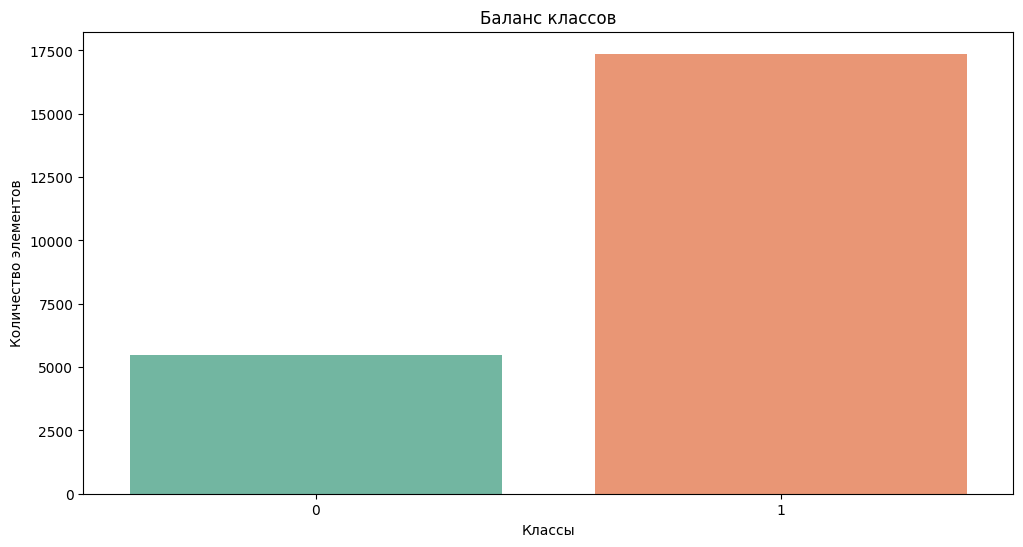

In [284]:
plt.figure(figsize=(12,6))
sns.countplot(x='real', data=df, hue='real', palette='Set2', legend=False)
plt.title('Баланс классов')
plt.xlabel('Классы')
plt.ylabel('Количество элементов')
plt.show()

### Шаг 2. Подготовка данных и токенизация

In [285]:
df['full'] = df['title'] + ' ' + df['news_url'] + ' ' + df['source_domain']

In [286]:
df.head()

,title,news_url,source_domain,tweet_num,real,full
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1,Kandi Burruss Explodes Over Rape Accusation on...
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1,People's Choice Awards 2018: The best red carp...
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1,Sophia Bush Sends Sweet Birthday Message to 'O...
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1,Colombian singer Maluma sparks rumours of inap...
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1,Gossip Girl 10 Years Later: How Upper East Sid...


In [287]:
def preprocess_text(text):
    # Удаляем знаки препинания
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Приводим к нижнему регистру
    text = text.lower()

    # Токенизация текста
    tokens = word_tokenize(text)

    # Удаляем стоп-слова
    tokens = [word for word in tokens if word.lower() not in stop_words]

    # Удаляем числа и другие символы
    tokens = [word for word in tokens if word.isalpha()]

    # Склеиваем токены обратно в строку
    preprocessed_text = ' '.join(tokens)

    return preprocessed_text

In [288]:
def preprocess_dataframe(dataframe, text_column):
    # Применяем preprocess_text ко всем значениям в указанной колонке
    dataframe[text_column] = dataframe[text_column].apply(preprocess_text)

    return dataframe

In [289]:
preprocess_dataframe(df, 'full')

,title,news_url,source_domain,tweet_num,real,full
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1,kandi burruss explodes rape accusation real ho...
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1,peoples choice awards best red carpet looks ww...
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1,sophia bush sends sweet birthday message one t...
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1,colombian singer maluma sparks rumours inappro...
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1,gossip girl years later upper east siders shoc...
...,...,...,...,...,...,...
23191,Pippa Middleton wedding: In case you missed it...,https://www.express.co.uk/news/royal/807049/pi...,www.express.co.uk,52,1,pippa middleton wedding case missed itpippa ma...
23192,Zayn Malik & Gigi Hadid’s Shocking Split: Why ...,hollywoodlife.com/2018/03/13/zayn-malik-gigi-h...,hollywoodlife.com,7,0,zayn malik gigi hadid shocking split chance re...
23193,Jessica Chastain Recalls the Moment Her Mother...,http://www.justjared.com/2018/01/17/jessica-ch...,www.justjared.com,26,1,jessica chastain recalls moment mothers boyfri...
23194,"Tristan Thompson Feels ""Dumped"" After Khloé Ka...",www.intouchweekly.com/posts/tristan-thompson-f...,www.intouchweekly.com,24,0,tristan thompson feels dumped khloé kardashian...


In [290]:
def len_text(text):
    words = text.split()
    return len(words)

In [291]:
max_sequence_length = int(df['full'].apply(len_text).max())

In [323]:
X_train, X_test, y_train, y_test = train_test_split(df[['full']], df['real'], test_size=0.2, random_state=42, stratify=df['real'])

In [324]:
X_train.shape, X_test.shape

((18292, 1), (4574, 1))

In [325]:
y_train.shape, y_test.shape

((18292,), (4574,))

### Шаг 3. Обучение Word2Vec в Gensim

In [326]:
sentences = []
for index, row in df.iterrows():
    sentences.append([word for word in row['full'].split()])
len(sentences)

22866

In [327]:
model_wv = Word2Vec(
    sentences=sentences,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=1,
    workers=4,
    epochs=10,     
    sg=1 # контекст по центральному слову
)

In [328]:
model_wv.build_vocab(sentences)
vocab_size = len(model_wv.wv)
print('Размер словаря:', vocab_size)

Размер словаря: 26724


In [329]:
model_wv.train(sentences, total_examples=model_wv.corpus_count, epochs=N_EPOCHS)

(2487782, 2524524)

In [330]:
vectors = model_wv.wv.vectors
vectors.shape

(26724, 128)

In [331]:
unk_vector = np.zeros(model_wv.vector_size)
pad_vector = np.zeros(model_wv.vector_size)

In [332]:
def text_to_vectors(text_tokens, model, max_len, unk_vector, pad_vector):
    
    vectors = []
    for token in text_tokens:
        if token in model.wv:
            vectors.append(model.wv[token])
        else:
            vectors.append(unk_vector)
    
    # Паддинг / обрезка
    if len(vectors) < max_len:
        vectors += [pad_vector] * (max_len - len(vectors))
    else:
        vectors = vectors[:max_len]
    
    return np.array(vectors, dtype=np.float32)

In [333]:
X_train_sent = []
for index, row in X_train.iterrows():
    X_train_sent.append([word for word in row['full'].split()])
len(X_train_sent)

18292

In [334]:
X_test_sent = []
for index, row in X_test.iterrows():
    X_test_sent.append([word for word in row['full'].split()])
len(X_test_sent)

4574

In [335]:
X_train_vect = np.array(
    [text_to_vectors(doc, model_wv, max_sequence_length, unk_vector, pad_vector) for doc in X_train_sent]
)
X_train_vect.shape

(18292, 36, 128)

In [336]:
X_test_vect = np.array(
    [text_to_vectors(doc, model_wv, max_sequence_length, unk_vector, pad_vector) for doc in X_test_sent]
)
X_test_vect.shape

(4574, 36, 128)

### Шаг 4. Обучение моделей в TensorFlow, получение метрик

#### 4.1 Recurrent Neural Network

In [358]:
model_rnn = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(units=UNITS, input_shape=(max_sequence_length, EMBEDDING_DIM)),
    tf.keras.layers.Dense(1, activation='sigmoid')  # для бинарной классификации
])

# Используем early_stop, который прекращает обучение, когда validation loss больше не улучшается
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Компиляция модели
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 
                                                                         metrics.Recall(name='recall'), metrics.AUC(name='auc')])

# Обучение модели
history_rnn = model_rnn.fit(
    X_train_vect, 
    y_train, 
    epochs=N_EPOCHS, 
    validation_split=VAL_SPLIT, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    #callbacks=[early_stop]
)

Epoch 1/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7523 - auc: 0.5674 - loss: 0.5483 - recall: 0.9617 - val_accuracy: 0.7436 - val_auc: 0.7610 - val_loss: 0.5236 - val_recall: 0.7833
Epoch 2/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8055 - auc: 0.7161 - loss: 0.4720 - recall: 0.9529 - val_accuracy: 0.8404 - val_auc: 0.7598 - val_loss: 0.4210 - val_recall: 0.9767
Epoch 3/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8291 - auc: 0.7792 - loss: 0.4327 - recall: 0.9517 - val_accuracy: 0.8245 - val_auc: 0.8139 - val_loss: 0.4222 - val_recall: 0.9089
Epoch 4/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8350 - auc: 0.8144 - loss: 0.4107 - recall: 0.9466 - val_accuracy: 0.8360 - val_auc: 0.8155 - val_loss: 0.3993 - val_recall: 0.9361
Epoch 5/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8469 - auc: 0.8285 - loss: 0.3937 - recall: 0.9563 - val_accuracy: 0.8439 - val_auc: 0.8254 - val_loss: 0.3909 - val_recall: 0.9587
Epoch 6/12

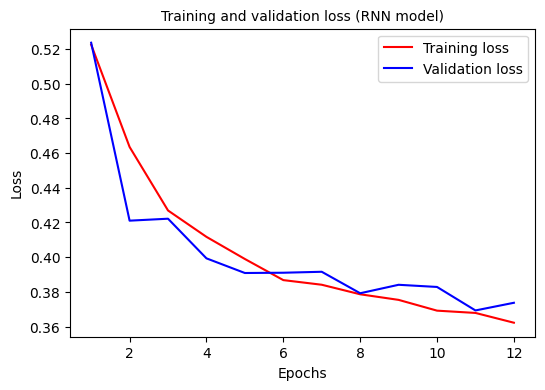

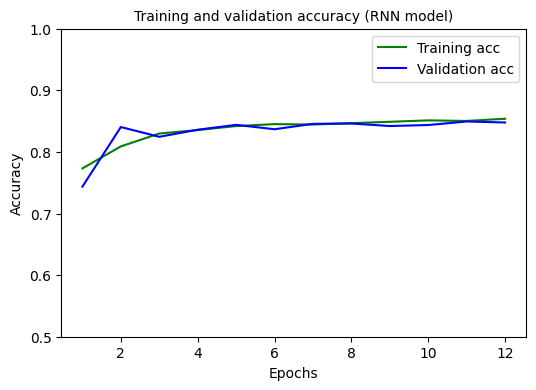

In [359]:
history_dict_rnn = history_rnn.history

acc_rnn = history_dict_rnn['accuracy']
val_acc_rnn = history_dict_rnn['val_accuracy']
loss_rnn = history_dict_rnn['loss']
val_loss_rnn = history_dict_rnn['val_loss']
epochs_rnn = [epoch + 1 for epoch in history_rnn.epoch]
          
plt.figure(figsize=(6,4))
plt.plot(epochs_rnn, loss_rnn, 'r', label='Training loss')
plt.plot(epochs_rnn, val_loss_rnn, 'b', label='Validation loss')
plt.title('Training and validation loss (RNN model)', size=10)
plt.xlabel('Epochs', size=10)
plt.ylabel('Loss', size=10)
plt.legend(prop={'size': 10})
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_rnn, acc_rnn, 'g', label='Training acc')
plt.plot(epochs_rnn, val_acc_rnn, 'b', label='Validation acc')
plt.title('Training and validation accuracy (RNN model)', size=10)
plt.xlabel('Epochs', size=10)
plt.ylabel('Accuracy', size=10)
plt.legend(prop={'size': 10})
plt.ylim((0.5,1))
plt.show()

143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8473983384346305
F1 Score: 0.9051114736269712
ROC AUC Score: 0.8485316278369479


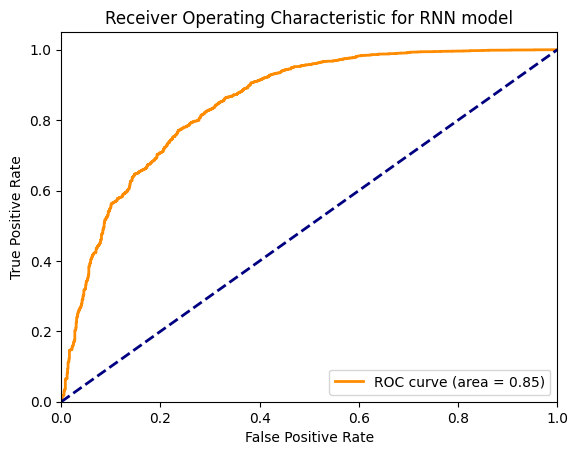

In [360]:
# Получаем предсказания
y_pred_rnn = model_rnn.predict(X_test_vect)

# Округляем вероятности до 0 или 1
y_pred_binary_rnn = np.round(y_pred_rnn)

# Оцениваем производительность модели
accuracy_rnn = accuracy_score(y_test, y_pred_binary_rnn)
f1_rnn = f1_score(y_test, y_pred_binary_rnn)
roc_auc_rnn = roc_auc_score(y_test, y_pred_rnn)

# Выводим результаты
print("Accuracy:", accuracy_rnn)
print("F1 Score:", f1_rnn)
print("ROC AUC Score:", roc_auc_rnn)

# Строим ROC-кривую
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, y_pred_rnn)
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)

plt.figure()
plt.plot(fpr_rnn, tpr_rnn, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_rnn)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for RNN model')
plt.legend(loc="lower right")
plt.show()

#### 4.2 Long Short‑Term Memory

In [317]:
model_lstm = tf.keras.Sequential([
    tf.keras.layers.LSTM(units=UNITS, input_shape=(max_sequence_length, EMBEDDING_DIM)),
    tf.keras.layers.Dense(1, activation='sigmoid')  # для бинарной классификации
])

# Компиляция модели
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 
                                                                         metrics.Recall(name='recall'), metrics.AUC(name='auc')])

# Обучение модели
history_lstm = model_lstm.fit(
    X_train_vect, 
    y_train, 
    epochs=N_EPOCHS, 
    validation_split=VAL_SPLIT, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    #callbacks=[early_stop]
)

Epoch 1/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7908 - auc: 0.6919 - loss: 0.5013 - recall: 0.9571 - val_accuracy: 0.8366 - val_auc: 0.8517 - val_loss: 0.3967 - val_recall: 0.9137
Epoch 2/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8496 - auc: 0.8495 - loss: 0.3715 - recall: 0.9455 - val_accuracy: 0.8420 - val_auc: 0.8597 - val_loss: 0.3931 - val_recall: 0.9613
Epoch 3/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8544 - auc: 0.8689 - loss: 0.3535 - recall: 0.9587 - val_accuracy: 0.8437 - val_auc: 0.8651 - val_loss: 0.3845 - val_recall: 0.9675
Epoch 4/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8628 - auc: 0.8827 - loss: 0.3331 - recall: 0.9563 - val_accuracy: 0.8347 - val_auc: 0.8664 - val_loss: 0.3740 - val_recall: 0.9794
Epoch 5/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8687 - auc: 0.8932 - loss: 0.3238 - recall: 0.9599 - val_accuracy: 0.8467 - val_auc: 0.8722 - val_loss: 0.3620 - val_recall: 0.9556
Epoch 6/12

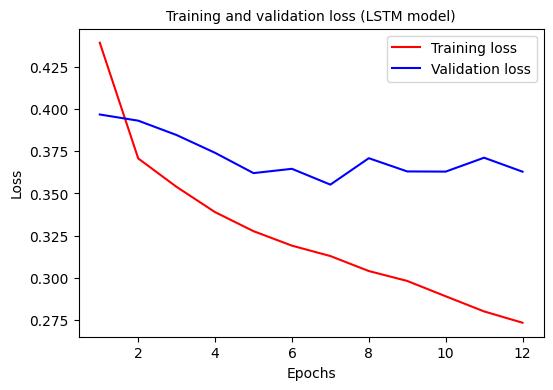

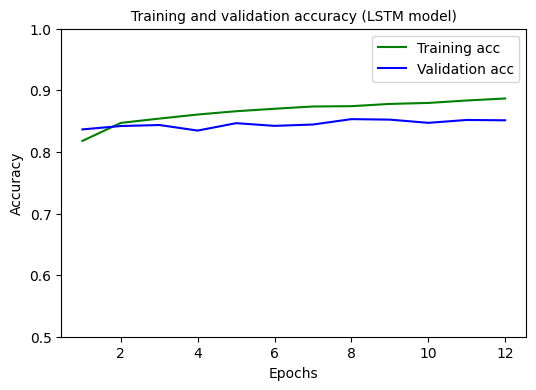

In [318]:
history_dict_lstm = history_lstm.history

acc_lstm = history_dict_lstm['accuracy']
val_acc_lstm = history_dict_lstm['val_accuracy']
loss_lstm = history_dict_lstm['loss']
val_loss_lstm = history_dict_lstm['val_loss']
epochs_lstm = [epoch + 1 for epoch in history_lstm.epoch]
          
plt.figure(figsize=(6,4))
plt.plot(epochs_lstm, loss_lstm, 'r', label='Training loss')
plt.plot(epochs_lstm, val_loss_lstm, 'b', label='Validation loss')
plt.title('Training and validation loss (LSTM model)', size=10)
plt.xlabel('Epochs', size=10)
plt.ylabel('Loss', size=10)
plt.legend(prop={'size': 10})
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_lstm, acc_lstm, 'g', label='Training acc')
plt.plot(epochs_lstm, val_acc_lstm, 'b', label='Validation acc')
plt.title('Training and validation accuracy (LSTM model)', size=10)
plt.xlabel('Epochs', size=10)
plt.ylabel('Accuracy', size=10)
plt.legend(prop={'size': 10})
plt.ylim((0.5,1))
plt.show()

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy: 0.8554875382597289
F1 Score: 0.9073580939032936
ROC AUC Score: 0.8819257574196275


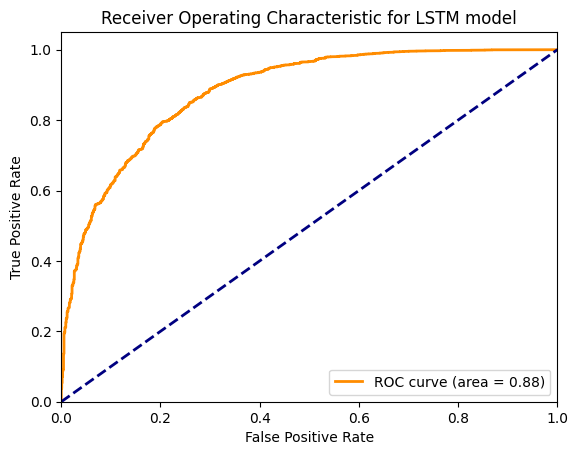

In [319]:
# Получаем предсказания
y_pred_lstm = model_lstm.predict(X_test_vect)

# Округляем вероятности до 0 или 1
y_pred_binary_lstm = np.round(y_pred_lstm)

# Оцениваем производительность модели
accuracy_lstm = accuracy_score(y_test, y_pred_binary_lstm)
f1_lstm = f1_score(y_test, y_pred_binary_lstm)
roc_auc_lstm = roc_auc_score(y_test, y_pred_lstm)

# Выводим результаты
print("Accuracy:", accuracy_lstm)
print("F1 Score:", f1_lstm)
print("ROC AUC Score:", roc_auc_lstm)

# Строим ROC-кривую
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_pred_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

plt.figure()
plt.plot(fpr_lstm, tpr_lstm, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_lstm)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for LSTM model')
plt.legend(loc="lower right")
plt.show()

#### 4.3 Gated Recurrent Unit

In [320]:
model_gru = tf.keras.Sequential([
    tf.keras.layers.GRU(units=UNITS, input_shape=(max_sequence_length, EMBEDDING_DIM)),
    tf.keras.layers.Dense(1, activation='sigmoid')  # для бинарной классификации
])

# Компиляция модели
model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 
                                                                         metrics.Recall(name='recall'), metrics.AUC(name='auc')])

# Обучение модели
history_gru = model_gru.fit(
    X_train_vect,
    y_train, 
    epochs=N_EPOCHS, 
    validation_split=VAL_SPLIT, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    #callbacks=[early_stop]
)

Epoch 1/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7728 - auc: 0.6807 - loss: 0.5167 - recall: 0.9664 - val_accuracy: 0.8311 - val_auc: 0.8513 - val_loss: 0.3947 - val_recall: 0.9335
Epoch 2/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8467 - auc: 0.8545 - loss: 0.3744 - recall: 0.9449 - val_accuracy: 0.8429 - val_auc: 0.8595 - val_loss: 0.3761 - val_recall: 0.9613
Epoch 3/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8567 - auc: 0.8730 - loss: 0.3517 - recall: 0.9537 - val_accuracy: 0.8450 - val_auc: 0.8624 - val_loss: 0.3674 - val_recall: 0.9624
Epoch 4/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8638 - auc: 0.8860 - loss: 0.3324 - recall: 0.9561 - val_accuracy: 0.8426 - val_auc: 0.8655 - val_loss: 0.3672 - val_recall: 0.9650
Epoch 5/12
458/458 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8654 - auc: 0.8890 - loss: 0.3310 - recall: 0.9605 - val_accuracy: 0.8429 - val_auc: 0.8673 - val_loss: 0.3800 - val_recall: 0.9259
Epoch 6/12

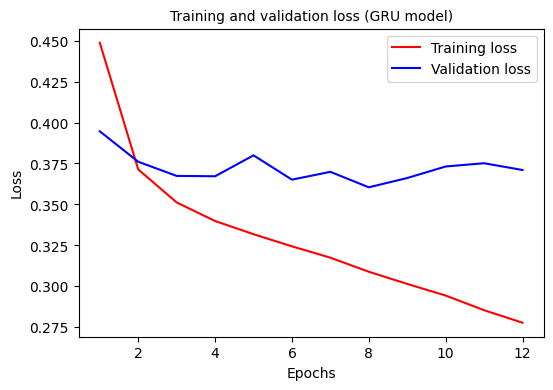

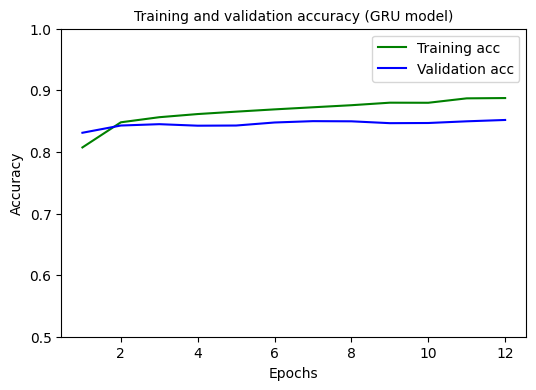

In [321]:
history_dict_gru = history_gru.history

acc_gru = history_dict_gru['accuracy']
val_acc_gru = history_dict_gru['val_accuracy']
loss_gru = history_dict_gru['loss']
val_loss_gru = history_dict_gru['val_loss']
epochs_gru = [epoch + 1 for epoch in history_gru.epoch]
          
plt.figure(figsize=(6,4))
plt.plot(epochs_gru, loss_gru, 'r', label='Training loss')
plt.plot(epochs_gru, val_loss_gru, 'b', label='Validation loss')
plt.title('Training and validation loss (GRU model)', size=10)
plt.xlabel('Epochs', size=10)
plt.ylabel('Loss', size=10)
plt.legend(prop={'size': 10})
plt.show()

plt.figure(figsize=(6,4))
plt.plot(epochs_gru, acc_gru, 'g', label='Training acc')
plt.plot(epochs_gru, val_acc_gru, 'b', label='Validation acc')
plt.title('Training and validation accuracy (GRU model)', size=10)
plt.xlabel('Epochs', size=10)
plt.ylabel('Accuracy', size=10)
plt.legend(prop={'size': 10})
plt.ylim((0.5,1))
plt.show()

143/143 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy: 0.8511149978137298
F1 Score: 0.9062112656658863
ROC AUC Score: 0.871166074696504


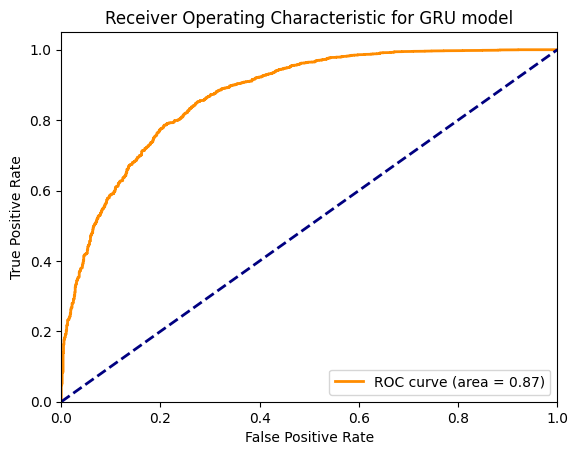

In [322]:
# Получаем предсказания
y_pred_gru = model_gru.predict(X_test_vect)

# Округляем вероятности до 0 или 1
y_pred_binary_gru = np.round(y_pred_gru)

# Оцениваем производительность модели
accuracy_gru = accuracy_score(y_test, y_pred_binary_gru)
f1_gru = f1_score(y_test, y_pred_binary_gru)
roc_auc_gru = roc_auc_score(y_test, y_pred_gru)

# Выводим результаты
print("Accuracy:", accuracy_gru)
print("F1 Score:", f1_gru)
print("ROC AUC Score:", roc_auc_gru)

# Строим ROC-кривую
fpr_gru, tpr_gru, _ = roc_curve(y_test, y_pred_gru)
roc_auc_gru = auc(fpr_gru, tpr_gru)

plt.figure()
plt.plot(fpr_gru, tpr_gru, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_gru)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for GRU model')
plt.legend(loc="lower right")
plt.show()